# 1. Introduction

This project focuses on analyzing a movie dataset.

# 2. Data Loading and Preprocessing

### 2.1. Load the dataset and libraries

In [41]:
import pandas as pd

In [42]:
df = pd.read_csv('Letterbox Movie Classification Dataset.csv')

df.head()

,Unnamed: 0,Film_title,Director,Average_rating,Genres,Runtime,Original_language,Description,Studios,Watches,List_appearances,Likes,Fans,Lowest★,Medium★★★,Highest★★★★★,Total_ratings
0,0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,German,The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,129,1660,714,9042
1,1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,English,An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,12530,158356,511140,1682389
2,2,Suspiria,Dario Argento,3.93,['Horror'],99.0,English,An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,2814,53427,88628,443757
3,3,Lost in Translation,Sofia Coppola,3.79,"['Drama', 'Comedy', 'Romance']",102.0,English,"Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,15167,155110,193717,1076949
4,4,Akira,Katsuhiro Otomo,4.28,"['Animation', 'Action', 'Science Fiction']",124.0,Japanese,A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,1822,40850,196532,600721


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10000 non-null  int64  
 1   Film_title         10000 non-null  str    
 2   Director           10000 non-null  str    
 3   Average_rating     10000 non-null  float64
 4   Genres             10000 non-null  str    
 5   Runtime            10000 non-null  float64
 6   Original_language  10000 non-null  str    
 7   Description        10000 non-null  str    
 8   Studios            10000 non-null  str    
 9   Watches            10000 non-null  int64  
 10  List_appearances   10000 non-null  int64  
 11  Likes              10000 non-null  int64  
 12  Fans               10000 non-null  int64  
 13  Lowest★            10000 non-null  int64  
 14  Medium★★★          10000 non-null  int64  
 15  Highest★★★★★       10000 non-null  int64  
 16  Total_ratings      10000 non-null 

### 2.2. Preprocessing

Save top 10 and worst 10 film titles

In [44]:
top10_films = df.sort_values(by='Average_rating', ascending=False).head(10)[['Film_title', 'Average_rating']]
worst10_films = df.sort_values(by='Average_rating', ascending=True).head(10)[['Film_title', 'Average_rating']]

Deleting unnecessary columns.

In [45]:
df.drop(columns=['Unnamed: 0', 'Film_title', 'Description', 'Likes', 'Fans', 'Lowest★', 'Medium★★★', 'Highest★★★★★'], inplace=True)

#### 2.2.1 Genres

Cleaning the 'Genres' column by converting string representations into Python lists

In [46]:
unique_genres = dict()
df['Genres'] = df['Genres'].astype(object)

for i, s in enumerate(df['Genres']):
    s = s.strip("[]").replace("'", "")
    l = []
    for g in s.split(','):
        l.append(g.strip())
        
        unique_genres[g.strip()] = unique_genres.get(g.strip(), 0) + 1
    df.at[i, 'Genres'] = l
    

In [47]:
unique_genres = pd.DataFrame(unique_genres.items(), columns=['Genre', 'Count'])
unique_genres.sort_values(by='Count', ascending=False, inplace=True)

Filtering for top genres

In [48]:
top_genres = unique_genres[unique_genres['Count']>200]['Genre'].tolist()
top_genres

['Drama',
 'Comedy',
 'Thriller',
 'Action',
 'Horror',
 'Crime',
 'Adventure',
 'Romance',
 'Science Fiction',
 'Fantasy',
 'Mystery',
 'Family',
 'Animation',
 'History',
 'Documentary',
 'War',
 'Music',
 'Western',
 'TV Movie']

In [49]:
columns_to_drop = unique_genres[~unique_genres['Genre'].isin(top_genres)]['Genre'].tolist()
columns_to_drop

['Unknown',
 'Show All…',
 'Epic heroes',
 'Superheroes in action-packed battles with villains',
 'Epic adventure and breathtaking battles',
 'Epic history and literature',
 'Fantasy adventure',
 'heroism',
 'and swordplay',
 'Captivating vision and Shakespearean drama',
 'Historical battles and epic heroism']

In [50]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_encoded = mlb.fit_transform(df['Genres'])

genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

genre_df.drop(columns=columns_to_drop, inplace=True)

df = pd.concat([df, genre_df], axis=1)

df = df.drop('Genres', axis=1)

In [51]:
DF_WITH_GENRES = df.drop(['Average_rating','Director', 'Studios'], axis=1).copy()

In [52]:
df.head()

,Director,Average_rating,Runtime,Original_language,Studios,Watches,List_appearances,Total_ratings,Action,Adventure,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,Eckhart Schmidt,3.57,92.0,German,['Barbara Moorse Workshop'],12841,11032,9042,0,0,...,0,1,0,0,0,0,0,0,0,0
1,George Miller,4.18,121.0,English,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,1682389,1,1,...,0,0,0,0,0,1,0,0,0,0
2,Dario Argento,3.93,99.0,English,['Seda Spettacoli'],618171,220094,443757,0,0,...,0,1,0,0,0,0,0,0,0,0
3,Sofia Coppola,3.79,102.0,English,"['American Zoetrope', 'Elemental Films']",1596190,254180,1076949,0,0,...,0,0,0,0,1,0,0,0,0,0
4,Katsuhiro Otomo,4.28,124.0,Japanese,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,600721,1,0,...,0,0,0,0,0,1,0,0,0,0


#### 2.2.2 Studios

In [53]:
unique_studios = dict()
df['Studios'] = df['Studios'].astype(object)

for i, s in enumerate(df['Studios']):
    s = s.strip("[]").replace("'", "")
    l = []
    for g in s.split(','):
        l.append(g.strip())
        
        unique_studios[g.strip()] = unique_studios.get(g.strip(), 0) + 1
    df.at[i, 'Studios'] = l
    

In [54]:
unique_studios = pd.DataFrame(unique_studios.items(), columns=['Studio', 'Count'])
unique_studios.sort_values(by='Count', ascending=False, inplace=True)

In [55]:
unique_studios.head(50)

,Studio,Count
1,Warner Bros. Pictures,502
50,Paramount Pictures,423
74,Columbia Pictures,411
58,Universal Pictures,410
21,20th Century Fox,367
150,Metro-Goldwyn-Mayer,317
1306,Unknown,307
48,United Artists,165
151,New Line Cinema,146
81,Walt Disney Pictures,116


In [56]:
top_studios = unique_studios[unique_studios['Count']>=40]['Studio'].tolist()
top_studios.remove('Unknown')
top_studios

['Warner Bros. Pictures',
 'Paramount Pictures',
 'Columbia Pictures',
 'Universal Pictures',
 '20th Century Fox',
 'Metro-Goldwyn-Mayer',
 'United Artists',
 'New Line Cinema',
 'Walt Disney Pictures',
 'Lionsgate',
 'Film4 Productions',
 'Touchstone Pictures',
 'American International Pictures',
 'Relativity Media',
 'Working Title Films',
 'DreamWorks Pictures',
 'TriStar Pictures',
 'Orion Pictures',
 'Village Roadshow Pictures',
 'StudioCanal',
 'TOHO',
 'Miramax',
 'BBC Film',
 'Summit Entertainment',
 'Canal+',
 'Focus Features',
 'RKO Radio Pictures',
 'Regency Enterprises',
 'ARTE France Cinéma',
 'The Cannon Group',
 'Dimension Films',
 'New World Pictures',
 'Walt Disney Productions',
 'Amblin Entertainment',
 'Scott Rudin Productions',
 'TSG Entertainment',
 'Warner Bros. Animation',
 'France 2 Cinéma',
 'Warner Bros. Cartoons',
 'Golan-Globus Productions',
 'Imagine Entertainment',
 'Ingenious Media',
 'Film i Väst',
 'Fox Searchlight Pictures',
 'Marvel Studios',
 'Blumho

In [57]:
columns_to_drop = unique_studios[~unique_studios['Studio'].isin(top_studios)]['Studio'].tolist()
columns_to_drop

['Unknown',
 'Scott Free Productions',
 'DC Entertainment',
 'Legendary Pictures',
 'Wild Bunch',
 'American Zoetrope',
 'New Regency Pictures',
 'France 3 Cinéma',
 'Constantin Film',
 'Bron Studios',
 'Screen Gems',
 'Silver Pictures',
 'Toei Company',
 'BFI',
 'CJ Entertainment',
 'Castle Rock Entertainment',
 'Republic Pictures',
 'dentsu',
 'DreamWorks Animation',
 'Participant',
 'Voltage Pictures',
 'Davis Entertainment',
 'RatPac Entertainment',
 'FilmNation Entertainment',
 'UK Film Council',
 'Pixar',
 'Happy Madison Productions',
 'BBC',
 'Millennium Media',
 'PolyGram Filmed Entertainment',
 'CNC',
 'Pathé',
 'Carolco Pictures',
 'The De Laurentiis Company',
 'Icon Productions',
 'Mandate International',
 'The Weinstein Company',
 'Lucasfilm Ltd.',
 'Apatow Productions',
 'Hammer Film Productions',
 'New Zealand Film Commission',
 'Heyday Films',
 'Perfect World Pictures',
 'XYZ Films',
 'di Bonaventura Pictures',
 'Revolution Studios',
 'Showbox',
 'TF1 Films Production',


In [58]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

studio_encoded = mlb.fit_transform(df['Studios'])

studio_df = pd.DataFrame(studio_encoded, columns=mlb.classes_)

studio_df.drop(columns=columns_to_drop, inplace=True)

df = pd.concat([df, studio_df], axis=1)

df = df.drop('Studios', axis=1)

In [59]:
DF_WITH_GENRES_STUDIOS = df.drop(['Average_rating','Director'], axis=1).copy()

In [60]:
df.head()

,Director,Average_rating,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,...,TriStar Pictures,United Artists,Universal Pictures,Village Roadshow Pictures,Walt Disney Pictures,Walt Disney Productions,Warner Bros. Animation,Warner Bros. Cartoons,Warner Bros. Pictures,Working Title Films
0,Eckhart Schmidt,3.57,92.0,German,12841,11032,9042,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,George Miller,4.18,121.0,English,2488721,331681,1682389,1,1,0,...,0,0,0,1,0,0,0,0,1,0
2,Dario Argento,3.93,99.0,English,618171,220094,443757,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Sofia Coppola,3.79,102.0,English,1596190,254180,1076949,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Katsuhiro Otomo,4.28,124.0,Japanese,873068,175586,600721,1,0,1,...,0,0,0,0,0,0,0,0,0,0


#### 2.2.3 Director

In [61]:
top_directors = df['Director'].value_counts().head(50).index.tolist()

In [62]:
columns_to_drop = df[~df['Director'].isin(top_directors)]['Director'].tolist()
columns_to_drop


['Eckhart Schmidt',
 'George Miller',
 'Dario Argento',
 'Sofia Coppola',
 'Katsuhiro Otomo',
 'Mia Hansen-Løve',
 'George Lucas',
 'Carol Reed',
 'Michael Showalter',
 'Frank Pavich',
 'Jordan Peele',
 'David Lean',
 'Ben Wheatley',
 'John Carney',
 'Pete Docter',
 'Peter Weir',
 'Patty Jenkins',
 'Edward D. Wood Jr.',
 'Damien Chazelle',
 'John Hughes',
 'Julia Ducournau',
 'Sam Raimi',
 'Gillian Robespierre',
 'Quentin Tarantino',
 'Nicholas Meyer',
 'Rob Reiner',
 'Nicolas Winding Refn',
 'Roger Allers, Rob Minkoff',
 'David Robert Mitchell',
 'Peyton Reed',
 'Denis Villeneuve',
 'René Laloux',
 'Ivan Reitman',
 'Christian Marquand',
 'Richard Kelly',
 'Alejandro Jodorowsky',
 'Bong Joon Ho',
 'Hayao Miyazaki',
 'Tara Subkoff',
 'Charlie Kaufman',
 'David Lowery',
 'Gary Goddard',
 'Brad Bird',
 'Barry Jenkins',
 'Quentin Tarantino',
 'Luc Besson',
 'Zack Snyder',
 'Wes Anderson',
 'Tom Holland',
 'Peter Jackson',
 'Michael Mann',
 'John Singleton',
 'Mike Hodges',
 'Harmony Korine

In [63]:
# add one hot encoding for directors that are in top_directors, drop the rest
director_encoded = pd.get_dummies(df['Director'])
director_encoded.drop(columns=columns_to_drop, inplace=True)
df = pd.concat([df, director_encoded], axis=1)
df = df.drop('Director', axis=1)

In [64]:
DF_WITH_GENRES_STUDIOS_DIRECTORS = df.drop(['Average_rating'], axis=1).copy()

In [65]:
df.head()

,Average_rating,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,...,Steven Spielberg,Teruo Ishii,Tim Burton,Tony Scott,Uli Edel,Vincente Minnelli,Walter Hill,Wes Craven,William Witney,Woody Allen
0,3.57,92.0,German,12841,11032,9042,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,4.18,121.0,English,2488721,331681,1682389,1,1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,3.93,99.0,English,618171,220094,443757,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,3.79,102.0,English,1596190,254180,1076949,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
4,4.28,124.0,Japanese,873068,175586,600721,1,0,1,0,...,False,False,False,False,False,False,False,False,False,False


# 3. Data exploration and visualizations

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
sns.set_theme(style="white")

## 3.1 TOP 10 FILMS

In [67]:
top10_films

,Film_title,Average_rating
9811,Radiohead: In Rainbows - From the Basement,4.71
610,Harakiri,4.69
6720,Stop Making Sense,4.68
1906,Twin Peaks,4.63
115,Come and See,4.63
256,12 Angry Men,4.63
4154,Planet Earth II,4.63
2185,Over the Garden Wall,4.62
5659,Planet Earth,4.61
1842,Seven Samurai,4.61


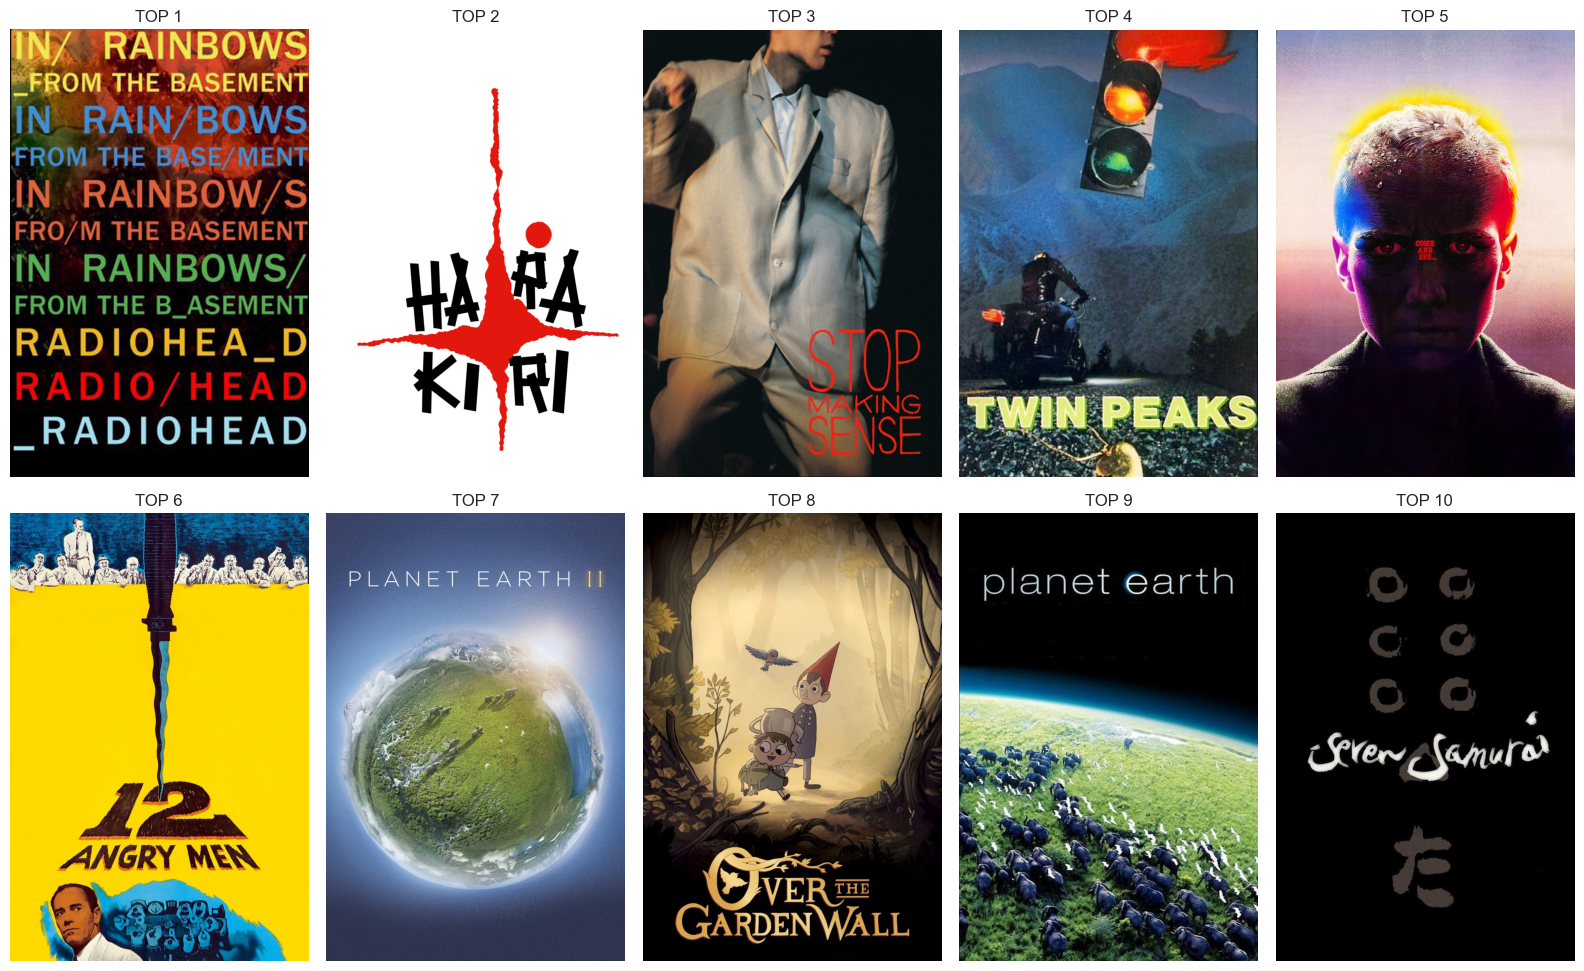

In [68]:
fig, axes = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(16, 10)
for i, film in enumerate(top10_films['Film_title'].values):
    img = Image.open(f"data\\top10\\top{i+1}.jpg")
    row = i // 5
    col = i % 5
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"TOP {i+1}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

This TOP 10 shows clearly that the letterboxd data is really "noisy" - the top rated movie apparently is a recording of a Radiohead concert...

...with this "Popular Review" on it: 

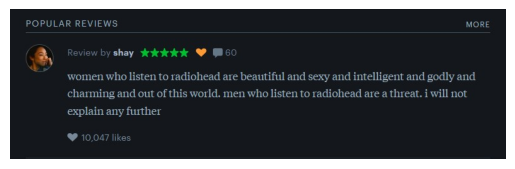

In [69]:
img = Image.open(f"data\\top10\\top1_xd.jpg")
plt.imshow(img)
plt.axis('off')
plt.show()

However we also have some valid masterpiece movies like "12 Angry Man" and "Seven Samurai"

## 3.2 WORST 10 FILMS

In [70]:
worst10_films

,Film_title,Average_rating
8177,365 Days,1.08
7698,Swiped,1.09
3220,The Last Airbender,1.11
4176,Son of the Mask,1.24
2506,Battlefield Earth,1.28
4178,Epic Movie,1.29
6097,Foodfight!,1.29
3812,Fantastic Four,1.34
7892,Artemis Fowl,1.35
1705,Alone in the Dark,1.35


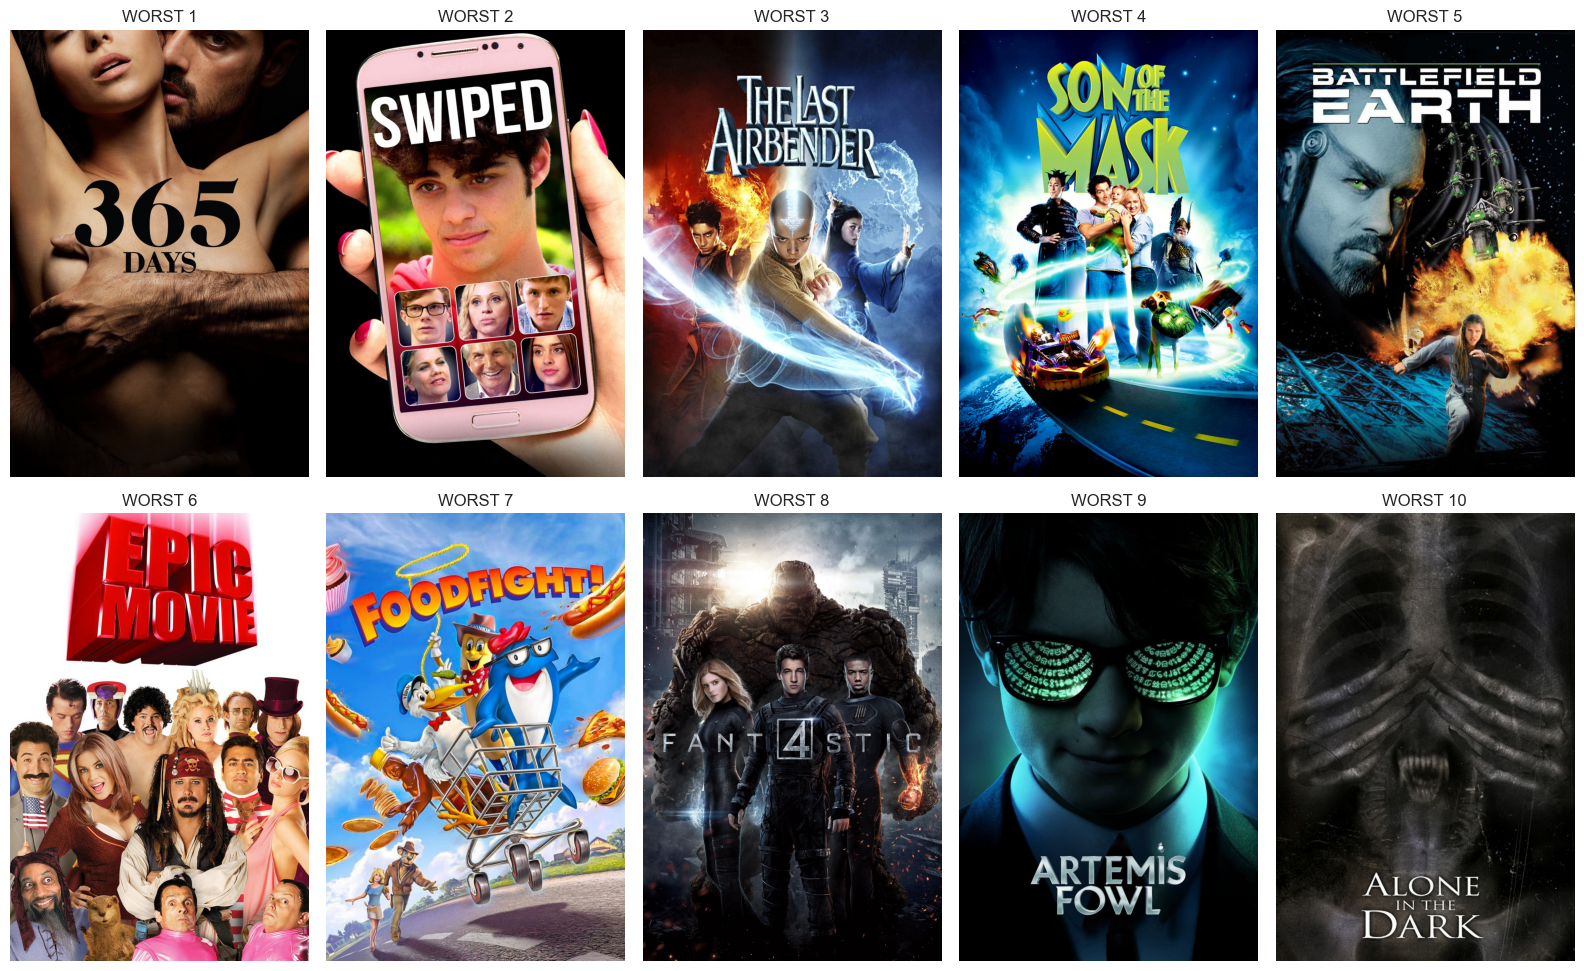

In [71]:
fig, axes = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(16, 10)
for i, film in enumerate(worst10_films['Film_title'].values):
    img = Image.open(f"data\\worst10\\worst{i+1}.jpg")
    row = i // 5
    col = i % 5
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"WORST {i+1}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

Hard to tell anything about those "works of art"

## 3.3 Dataset characteristics

### 3.3.1. General information about the dataset

In [72]:
df.shape 

(10000, 124)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 124 entries, Average_rating to Woody Allen
dtypes: bool(50), float64(2), int64(71), str(1)
memory usage: 6.2 MB


### 3.3.2. Average Rating 

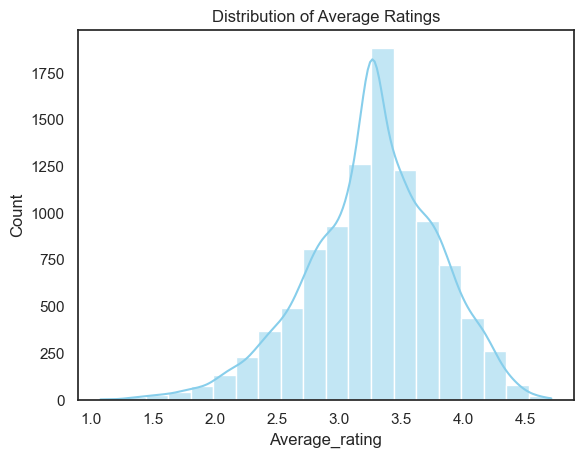

In [74]:

sns.histplot(df['Average_rating'], bins=20,kde=True, color='skyblue')
plt.title('Distribution of Average Ratings')

plt.show()

In [75]:
df['Average_rating'].describe()

count    10000.000000
mean         3.268535
std          0.525744
min          1.080000
25%          2.950000
50%          3.268535
75%          3.620000
max          4.710000
Name: Average_rating, dtype: float64

### 3.3.3. Runtime

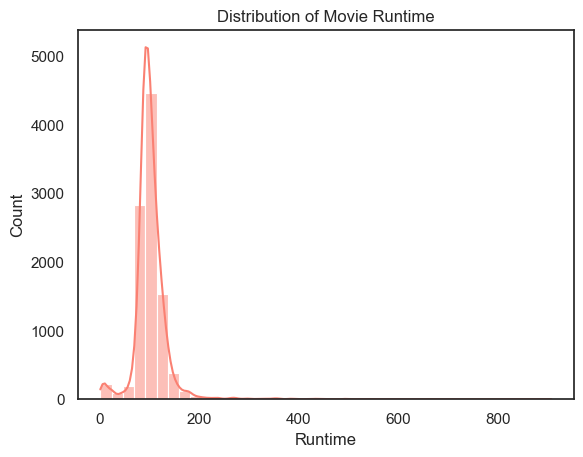

In [76]:
sns.histplot(df['Runtime'], bins=40,kde=True, color='salmon')
plt.title('Distribution of Movie Runtime')
plt.show()

In [77]:
df['Runtime'].describe()

count    10000.000000
mean       103.169352
std         38.070735
min          2.000000
25%         89.000000
50%         99.000000
75%        113.000000
max        907.000000
Name: Runtime, dtype: float64

### 3.3.4. Original Language

In [78]:
df['Original_language'].unique()

<ArrowStringArray>
[                          'German',                          'English',
                         'Japanese',                           'French',
                          'Spanish',                          'Italian',
                        'Cantonese',                       'Indonesian',
                           'Korean',               'No spoken language',
                          'Russian',                          'Swedish',
                           'Danish',                            'Dutch',
                           'Polish',                        'Hungarian',
                            'Mayan',                             'Thai',
                   'Greek (modern)',                  'Persian (Farsi)',
                        'Norwegian',                       'Portuguese',
                            'Czech',                          'Chinese',
                          'Turkish',                           'Telugu',
                           'Arab

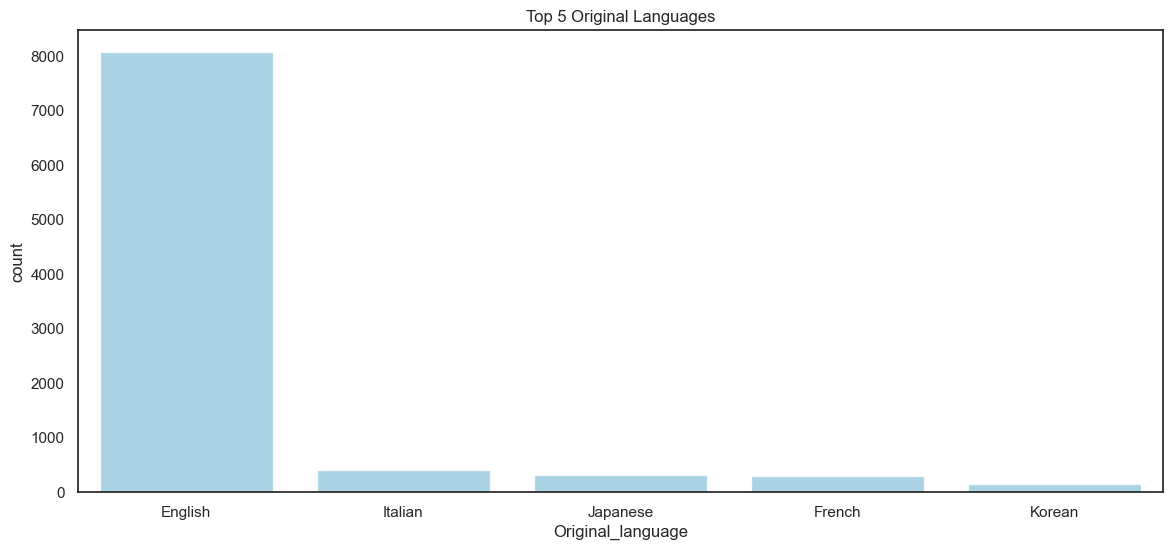

In [79]:
top_5_languages = df['Original_language'].value_counts().nlargest(5).index
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Original_language', order=top_5_languages, color='skyblue', alpha=0.8)
plt.title('Top 5 Original Languages')
plt.show()

In [80]:
counts = df['Original_language'].value_counts()
print(counts)

Original_language
English                             8074
Italian                              396
Japanese                             308
French                               291
Korean                               145
Spanish                              115
German                                96
No spoken language                    94
Chinese                               66
Danish                                60
Cantonese                             58
Russian                               43
Swedish                               32
Dutch                                 20
Polish                                20
Portuguese                            19
Romanian                              18
Persian (Farsi)                       15
Norwegian                             14
Arabic                                14
Czech                                 12
Hungarian                              9
Greek (modern)                         9
Hindi                                  

### 3.3.5. Watches, List_appearances, Total_ratings

In [81]:
df['Watches'].describe()

count    1.000000e+04
mean     1.703148e+05
std      4.585329e+05
min      2.000000e+00
25%      2.979750e+03
50%      1.842500e+04
75%      1.083580e+05
max      5.195503e+06
Name: Watches, dtype: float64

In [82]:
df['List_appearances'].describe()

count     10000.000000
mean      26868.798600
std       56751.328696
min          33.000000
25%        1674.000000
50%        6503.000000
75%       23908.250000
max      803670.000000
Name: List_appearances, dtype: float64

In [83]:
df['Total_ratings'].describe()

count    1.000000e+04
mean     1.063923e+05
std      2.947343e+05
min      0.000000e+00
25%      1.895000e+03
50%      1.182300e+04
75%      6.749875e+04
max      4.091037e+06
Name: Total_ratings, dtype: float64

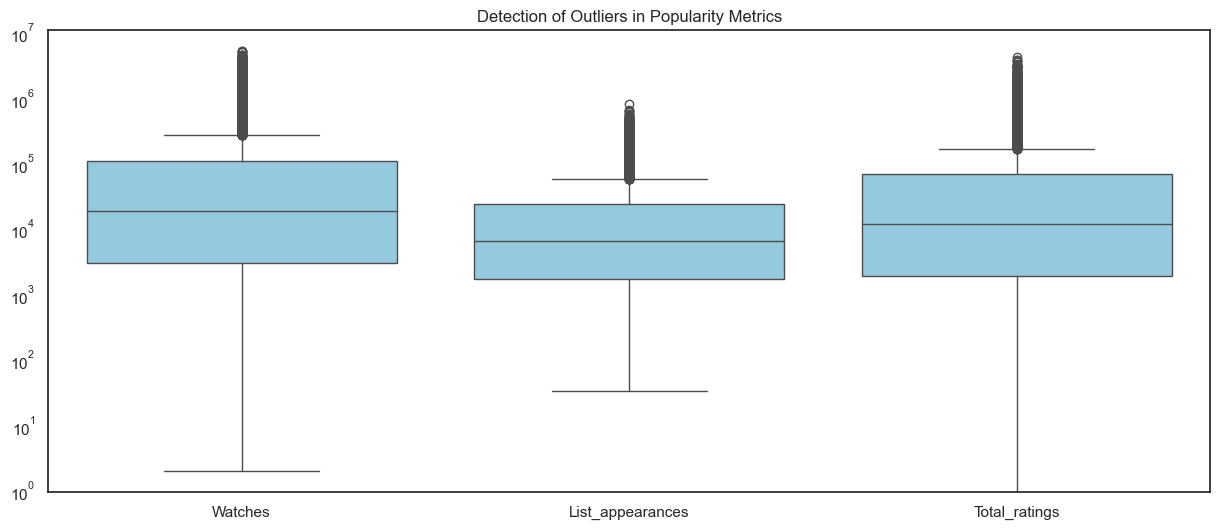

In [84]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[['Watches', 'List_appearances', 'Total_ratings']], color='skyblue') 
plt.yscale('log') # Set log scale for better visualization of outliers
plt.title('Detection of Outliers in Popularity Metrics')
plt.show()

### 3.3.6. Genres

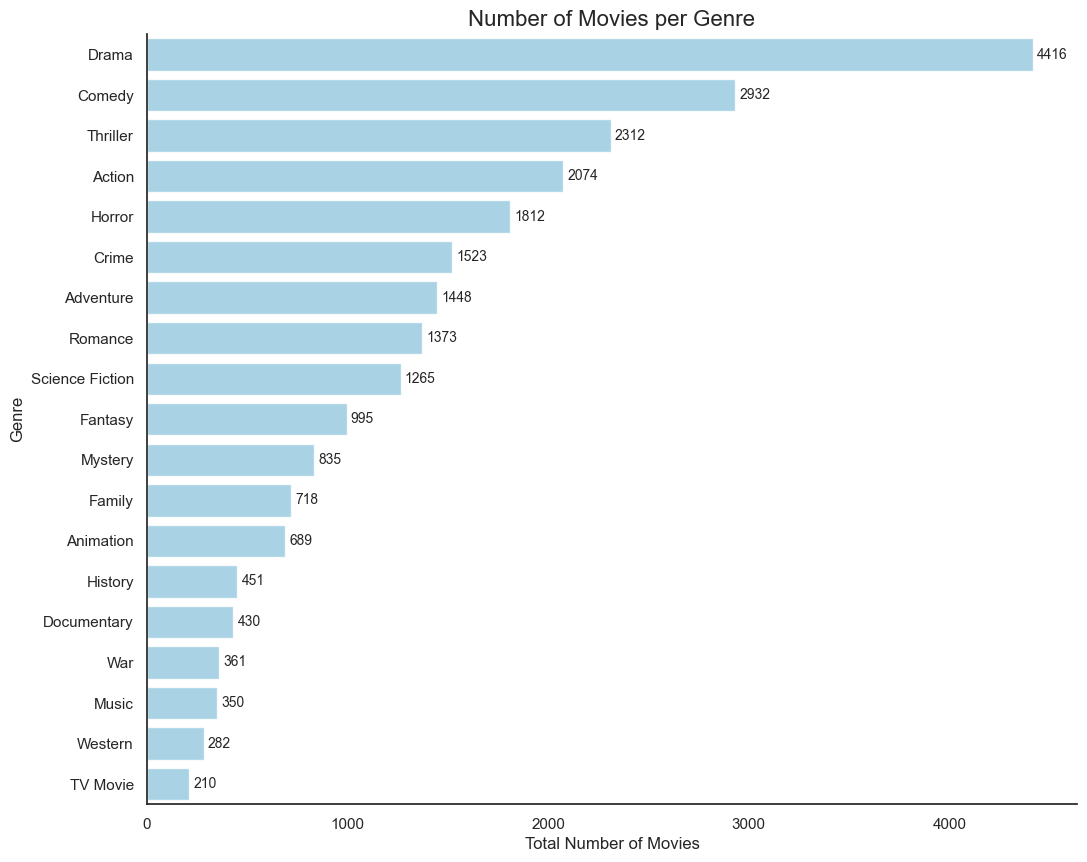

In [85]:
genre_counts = df[top_genres].sum().sort_values(ascending=False)

genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

plt.figure(figsize=(12, 10))

ax = sns.barplot(data=genre_df, x='Count', y='Genre', color='skyblue', alpha=0.8)

ax.bar_label(ax.containers[0], padding=3, fontsize=10)

plt.title('Number of Movies per Genre', fontsize=16)
plt.xlabel('Total Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)

sns.despine()

plt.show()


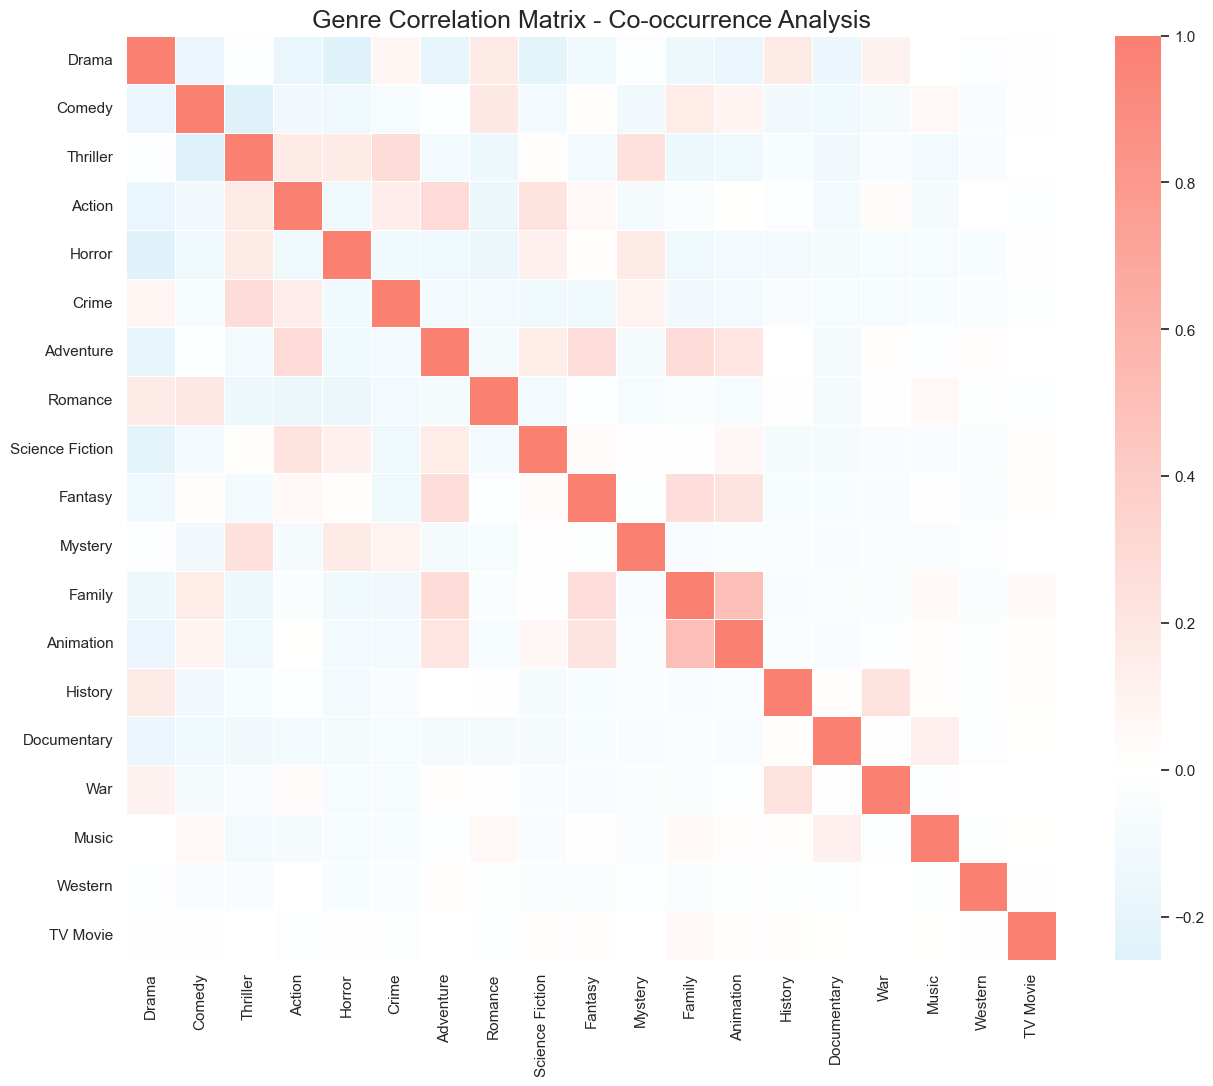

In [86]:
from matplotlib.colors import LinearSegmentedColormap

genre_data = df[top_genres]

genre_corr = genre_data.corr()

colors = ["skyblue", "white", "salmon"]
my_cmap = LinearSegmentedColormap.from_list("sky_salmon", colors)

plt.figure(figsize=(15, 12))


sns.heatmap(genre_corr, 
            annot=False, 
            cmap=my_cmap, 
            center=0, 
            linewidths=0.5, 
            linecolor='white')

plt.title('Genre Correlation Matrix - Co-occurrence Analysis', fontsize=18)
plt.show()

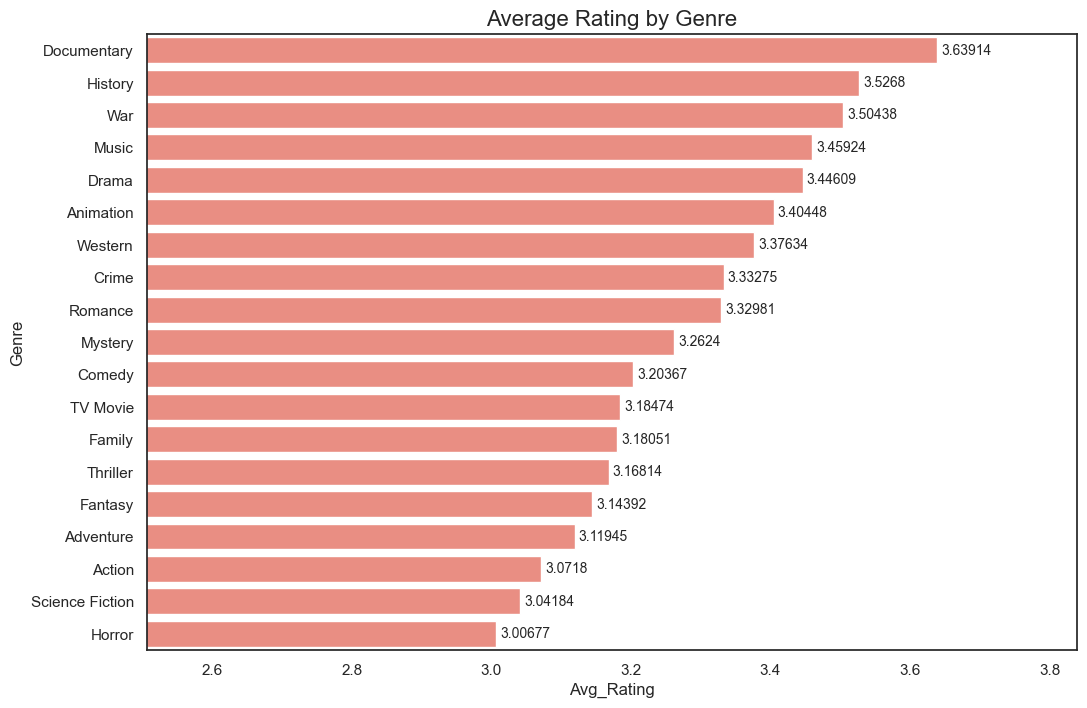

In [87]:
genre_means = {}
for g in top_genres:
    genre_means[g] = df[df[g] == 1]['Average_rating'].mean()

mean_df = pd.DataFrame(list(genre_means.items()), columns=['Genre', 'Avg_Rating']).sort_values('Avg_Rating', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=mean_df, x='Avg_Rating', y='Genre', color='salmon')
ax.bar_label(ax.containers[0], padding=3, fontsize=10)


plt.xlim(mean_df['Avg_Rating'].min() - 0.5, mean_df['Avg_Rating'].max() + 0.2)

plt.title('Average Rating by Genre', fontsize=16)
plt.show()

# 4. Classification column

We are creating new columns 'Rating_Class1' and 'Rating_Class2' based on the 'Average_rating' column.

In [88]:
def rating_class1(rating):

    '''
    Terrible: [0.0 to 2.5)
    Bad: [2.5 to 3.24)
    Average: [3.25 to 3.99)
    Best: [4.0 to 5.0)
    '''

    if rating < 2.5:
        return 'Terrible'
    elif rating < 3.25:
        return 'Bad'
    elif rating < 4:
        return 'Average'
    else:
        return 'Best'

df["Rating_Class1"] = df["Average_rating"].apply(rating_class1)
df['Rating_Class1'].value_counts()

Rating_Class1
Average     4895
Bad         3531
Terrible     798
Best         776
Name: count, dtype: int64

In [89]:
def rating_class2(rating):

    '''
    Bad/Mixed: [0.0 to 3.2)
    Good: [3.2 to 3.9)
    Masterpiece: [3.9 to 5.0)
    '''

    if rating < 3.2:
        return 'Bad/Mixed'
    elif rating < 3.9:
        return 'Good'
    else:
        return 'Masterpiece'

df["Rating_Class2"] = df["Average_rating"].apply(rating_class2)
df['Rating_Class2'].value_counts()

Rating_Class2
Good           4950
Bad/Mixed      3935
Masterpiece    1115
Name: count, dtype: int64

In [90]:
df.head(5)

,Average_rating,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,...,Tim Burton,Tony Scott,Uli Edel,Vincente Minnelli,Walter Hill,Wes Craven,William Witney,Woody Allen,Rating_Class1,Rating_Class2
0,3.57,92.0,German,12841,11032,9042,0,0,0,0,...,False,False,False,False,False,False,False,False,Average,Good
1,4.18,121.0,English,2488721,331681,1682389,1,1,0,0,...,False,False,False,False,False,False,False,False,Best,Masterpiece
2,3.93,99.0,English,618171,220094,443757,0,0,0,0,...,False,False,False,False,False,False,False,False,Average,Masterpiece
3,3.79,102.0,English,1596190,254180,1076949,0,0,0,1,...,False,False,False,False,False,False,False,False,Average,Good
4,4.28,124.0,Japanese,873068,175586,600721,1,0,1,0,...,False,False,False,False,False,False,False,False,Best,Masterpiece


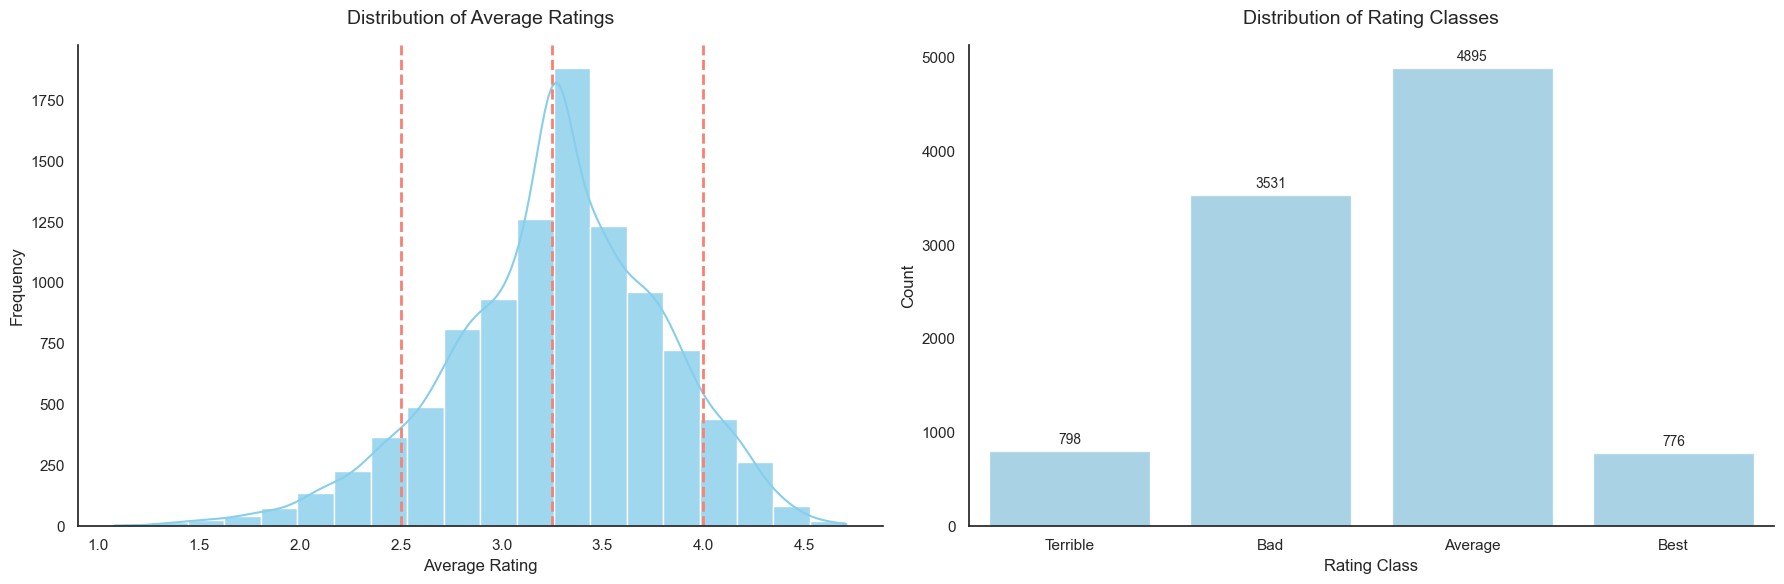

In [91]:
plot_data = df['Rating_Class1'].value_counts().reindex(['Terrible', 'Bad', 'Average', 'Best']).reset_index()
plot_data.columns = ['Rating Class', 'Count']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))


sns.histplot(df['Average_rating'], bins=20, color='skyblue', edgecolor='white', alpha=0.8, ax=ax1, kde=True)

for pos in [2.5, 3.25, 4.0]:
    ax1.axvline(x=pos, color='salmon', linestyle='--', linewidth=2, label='Class Border' if pos == 2.5 else "")

ax1.set_title('Distribution of Average Ratings', fontsize=14, pad=15)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')


sns.barplot(data=plot_data, x='Rating Class', y='Count', color='skyblue', alpha=0.8, ax=ax2)


ax2.bar_label(ax2.containers[0], padding=3, fontsize=10)

ax2.set_title('Distribution of Rating Classes', fontsize=14, pad=15)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')

sns.despine()
plt.tight_layout()
plt.show()

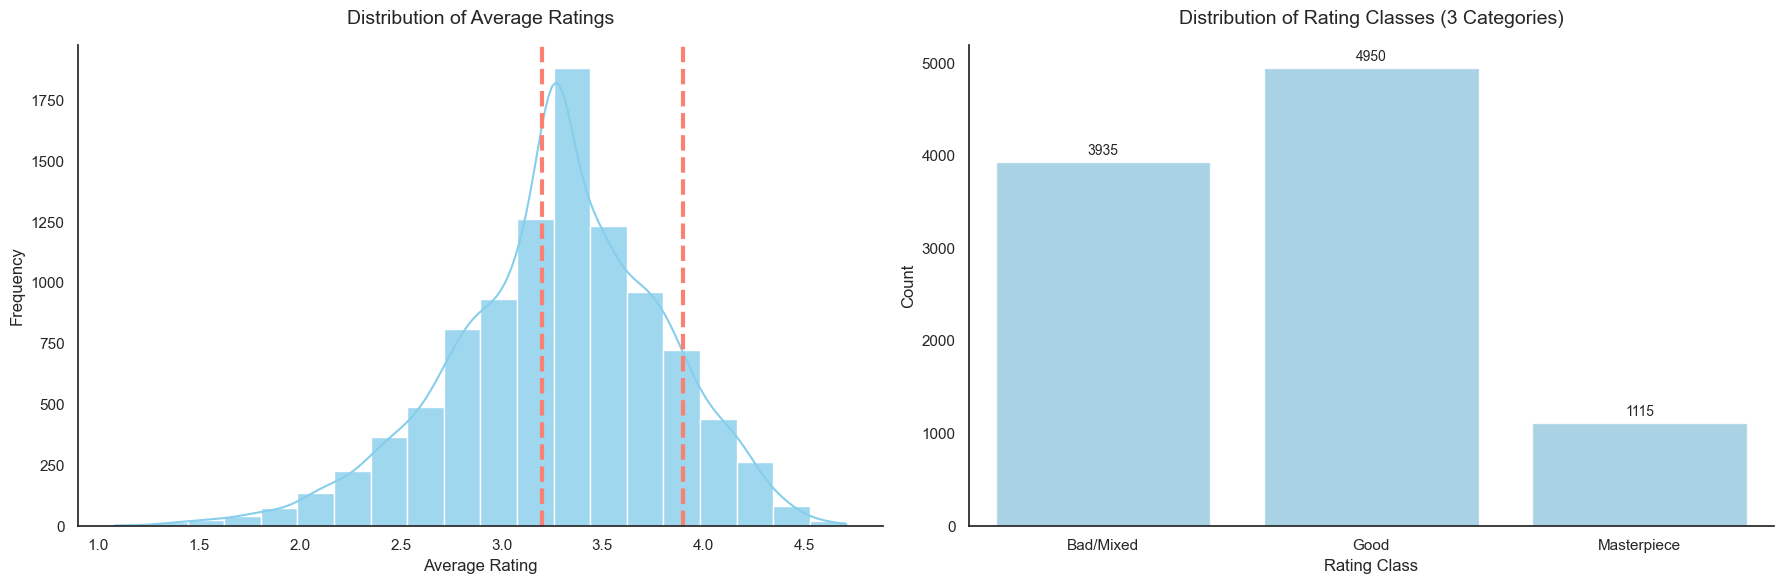

In [92]:
plot_data = df['Rating_Class2'].value_counts().reindex(['Bad/Mixed', 'Good', 'Masterpiece']).reset_index()
plot_data.columns = ['Rating Class', 'Count']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

sns.histplot(df['Average_rating'], bins=20, color='skyblue', edgecolor='white', alpha=0.8, ax=ax1, kde=True)

for pos in [3.2, 3.9]:
    ax1.axvline(x=pos, color='salmon', linestyle='--', linewidth=3, label='Threshold')

ax1.set_title('Distribution of Average Ratings', fontsize=14, pad=15)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')

sns.barplot(data=plot_data, x='Rating Class', y='Count', color='skyblue', alpha=0.8, ax=ax2)

ax2.bar_label(ax2.containers[0], padding=3, fontsize=10)

ax2.set_title('Distribution of Rating Classes (3 Categories)', fontsize=14, pad=15)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')

sns.despine() 
plt.tight_layout()
plt.show()

In [93]:
df.drop(columns=['Average_rating'], inplace=True)

# 5. Random Forest 

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report

In [95]:
y1=df['Rating_Class1']
y2=df['Rating_Class2']

In [96]:
# 1) DF with: Runtime Watches List_appearances Total_ratings 
# 4 columns
DF1 = df[['Runtime', 'Watches', 'List_appearances', 'Total_ratings']]

# 2) DF with: Runtime Watches List_appearances Total_ratings [one hot: Original_language]
# 61 columns
DF2 = pd.get_dummies(df[['Runtime', 'Watches', 'Original_language', 'List_appearances', 'Total_ratings']], columns=['Original_language'])

# 3) DF with: Runtime Watches List_appearances Total_ratings [one hot: Original_language] [one hot: Genres]
# 80 columns
DF3 = pd.get_dummies(DF_WITH_GENRES, columns=['Original_language'])

# 4) DF with: Runtime Watches List_appearances Total_ratings [one hot: Original_language] [one hot: Genres] [one hot: Studios]
# 129 columns
DF4 = pd.get_dummies(DF_WITH_GENRES_STUDIOS, columns=['Original_language'])

# 5) DF with: Runtime Watches List_appearances Total_ratings [one hot: Original_language] [one hot: Genres] [one hot: Studios] [one hot: Directors]
# 179 columns
DF5 = pd.get_dummies(DF_WITH_GENRES_STUDIOS_DIRECTORS, columns=['Original_language'])

In [186]:
dataframes = [DF1, DF2, DF3, DF4, DF5]
for dataframe in dataframes:
    print(dataframe.shape)

(10000, 4)
(10000, 61)
(10000, 80)
(10000, 129)
(10000, 179)


In [ ]:
scores_df = pd.DataFrame(columns=['Dataframe', 'RFC_rating_class1', 'RFC_rating_class2', 'Balanced RFC rating_class1', 'Balanced RFC rating_class2'])

for i, dataframe in enumerate(dataframes):
    print(f"Dataframe {i+1} shape: {dataframe.shape}")

    X1_train, X1_test, y1_train, y1_test = train_test_split(dataframe, y1, test_size=0.2, random_state=67)
    X2_train, X2_test, y2_train, y2_test = train_test_split(dataframe, y2, test_size=0.2, random_state=67)

    rf1 = RandomForestClassifier(n_estimators=500, random_state=67, max_features=0.5)
    rf1.fit(X1_train, y1_train)
    y1_pred = rf1.predict(X1_test)
    score1 = rf1.score(X1_test, y1_test)

    rf2 = RandomForestClassifier(n_estimators=500, random_state=67, max_features=0.5)
    rf2.fit(X2_train, y2_train)
    y2_pred = rf2.predict(X2_test)
    score2 = rf2.score(X2_test, y2_test)

    # ------------------------

    rf1_balanced = BalancedRandomForestClassifier(random_state=67,n_estimators=500, max_features=0.5)
    rf1_balanced.fit(X1_train, y1_train)
    y1_pred_balanced = rf1_balanced.predict(X1_test)
    score1_balanced = rf1_balanced.score(X1_test, y1_test)

    rf2_balanced = BalancedRandomForestClassifier(random_state=67,n_estimators=500, max_features=0.5)
    rf2_balanced.fit(X2_train, y2_train)
    y2_pred_balanced = rf2_balanced.predict(X2_test)
    score2_balanced = rf2_balanced.score(X2_test, y2_test)

    scores_df.loc[i] = [f"Dataframe {i+1}", score1, score2, score1_balanced, score2_balanced]

Dataframe 1 shape: (10000, 179)


In [192]:
scores_df

,Dataframe,RFC_rating_class1,RFC_rating_class2,Balanced RFC rating_class1,Balanced RFC rating_class2
0,Dataframe 1,0.7005,0.768,0.618,0.74


In [193]:
print("Classification Report for DF5 Rating_Class1:")
print(classification_report(y1_test, y1_pred))

print("Classification Report for DF5 Rating_Class2:")
print(classification_report(y2_test, y2_pred))

Classification Report for DF5 Rating_Class1:
              precision    recall  f1-score   support

     Average       0.77      0.80      0.78       989
         Bad       0.64      0.74      0.68       698
        Best       0.64      0.53      0.58       137
    Terrible       0.46      0.15      0.22       176

    accuracy                           0.70      2000
   macro avg       0.63      0.55      0.57      2000
weighted avg       0.69      0.70      0.69      2000

Classification Report for DF5 Rating_Class2:
              precision    recall  f1-score   support

   Bad/Mixed       0.79      0.79      0.79       805
        Good       0.75      0.80      0.77       986
 Masterpiece       0.74      0.57      0.64       209

    accuracy                           0.77      2000
   macro avg       0.76      0.72      0.74      2000
weighted avg       0.77      0.77      0.77      2000



## ALA

In [ ]:
X=pd.get_dummies(df, columns=['Original_language']).drop(columns=['Rating_Class1', 'Rating_Class2'])
y1=df['Rating_Class1']
y2=df['Rating_Class2']

In [ ]:
X1_train ,X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=67)
X2_train ,X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=67)

### 5.1. Imbalanced Data

In [ ]:
rf1 = RandomForestClassifier(n_estimators=500, random_state=67, max_features=0.5)
rf1.fit(X1_train, y1_train)
rf2 = RandomForestClassifier(n_estimators=500, random_state=67, max_features=0.5)
rf2.fit(X2_train, y2_train)

In [ ]:
y1_pred = rf1.predict(X1_test)
rf1.score(X1_test, y1_test)

In [ ]:
print("Classification Report for Rating_Class1:")
print(classification_report(y1_test, y1_pred))

In [ ]:
pd.DataFrame(rf1.feature_importances_, index = X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False).head(10)

In [ ]:
y2_pred = rf2.predict(X2_test)
rf2.score(X2_test, y2_test)

In [ ]:
print("Classification Report for Rating_Class2:")
print(classification_report(y2_test, y2_pred))

In [ ]:
pd.DataFrame(rf2.feature_importances_, index = X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False).head(10)

### 5.2. Balanced Data

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
rf1_balanced = BalancedRandomForestClassifier(random_state=67,n_estimators=500, max_features=0.5)
rf1_balanced.fit(X1_train, y1_train)
rf2_balanced = BalancedRandomForestClassifier(random_state=67,n_estimators=500, max_features=0.5)
rf2_balanced.fit(X2_train, y2_train)

In [ ]:
y1_pred = rf1_balanced.predict(X1_test)
rf1_balanced.score(X1_test, y1_test)

In [ ]:
print("Classification Report for Rating_Class1:")
print(classification_report(y1_test, y1_pred))

In [ ]:
y2_pred = rf2_balanced.predict(X2_test)
rf2_balanced.score(X2_test, y2_test)

In [ ]:
print("Classification Report for Rating_Class2:")
print(classification_report(y2_test, y2_pred))

# 6. CatBoost (ala)

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
df

In [ ]:
X = df.drop(columns=['Rating_Class1', 'Rating_Class2'])
y1 = df['Rating_Class1']
y2 = df['Rating_Class2']
cat_features = ['Original_language']

In [ ]:
X1_train ,X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=67)
X2_train ,X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=67)

In [ ]:
cb_model = CatBoostClassifier(
   iterations=500,        
    learning_rate=0.1,      
    depth=6,                  
    l2_leaf_reg=5, 
    class_weights=[1.0, 1.0, 2.5, 3.0], 
    cat_features=cat_features,
    verbose=False, 
    random_seed=67
)

In [ ]:
cb_model.fit(X1_train, y1_train)

In [ ]:
y_pred_cb = cb_model.predict(X1_test)
print(classification_report(y1_test, y_pred_cb))

# 7. XGBoost

In [97]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

In [98]:
y1=df['Rating_Class1']
y2=df['Rating_Class2']

Encode Rating_Class1 and Rating_Class2 (LableEncoder uses Alphabetical order!)

Class1: Average -> 0, Bad -> 1, Best -> 2, Terrible -> 3

Class2: Bad/Mixed -> 0, Good -> 1, Masterpiece -> 2

In [ ]:
label_encoder = LabelEncoder()
y1_encoded = label_encoder.fit_transform(y1)
y2_encoded = label_encoder.fit_transform(y2)

In [100]:
X1_train, X1_test, y1_train, y1_test = train_test_split(DF5, y1_encoded, test_size=0.2, random_state=67)
X2_train, X2_test, y2_train, y2_test = train_test_split(DF5, y2_encoded, test_size=0.2, random_state=67)

In [101]:
sample_weights_1 = compute_sample_weight(class_weight='balanced', y=y1_train)
sample_weights_2 = compute_sample_weight(class_weight='balanced', y=y2_train)

In [ ]:
for i in [1,2]:
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=67,
        eval_metric='mlogloss'
    )

    if i == 1:
        xgb_model.fit(X1_train, y1_train, sample_weight=sample_weights_1)
        y_pred_xgb = xgb_model.predict(X1_test)
        print(f"Classification Report for Rating_Class1:")
        print(classification_report(y1_test, y_pred_xgb))
        xgb_score = xgb_model.score(X1_test, y1_test)
        print(f"XGBoost Test Accuracy for Rating_Class1: {xgb_score:.4f}")
    
    else:
        xgb_model.fit(X2_train, y2_train, sample_weight=sample_weights_2)
        y_pred_xgb = xgb_model.predict(X2_test)
        print(f"\nClassification Report for Rating_Class2:")
        print(classification_report(y2_test, y_pred_xgb))
        xgb_score = xgb_model.score(X2_test, y2_test)
        print(f"XGBoost Test Accuracy for Rating_Class2: {xgb_score:.4f}")

Classification Report for Rating_Class1:
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       989
           1       0.62      0.60      0.61       698
           2       0.55      0.76      0.64       137
           3       0.34      0.56      0.42       176

    accuracy                           0.66      2000
   macro avg       0.58      0.65      0.61      2000
weighted avg       0.69      0.66      0.67      2000

XGBoost Test Accuracy for Rating_Class1: 0.6580
Classification Report for Rating_Class2:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       805
           1       0.79      0.68      0.73       986
           2       0.57      0.76      0.65       209

    accuracy                           0.75      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.76      0.75      0.75      2000

XGBoost Test Accuracy for Rating_Class2: 0.7495


# 8. CatBoost (tomek)

In [115]:
from catboost import CatBoostClassifier

for i in [1,2]:

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        random_seed=67,
        verbose=0
    )

    if i == 1:
        cat_model.fit(X1_train, y1_train, sample_weight=sample_weights_1)

        cat_score = cat_model.score(X1_test, y1_test)
        print(f"CatBoost Test Accuracy for Rating_Class1: {cat_score:.4f}")

        y_pred_cat = cat_model.predict(X1_test)
        print("\nClassification Report for CatBoost:")
        print(classification_report(y1_test, y_pred_cat))

    else:
        cat_model.fit(X2_train, y2_train, sample_weight=sample_weights_2)

        cat_score = cat_model.score(X2_test, y2_test)
        print(f"CatBoost Test Accuracy for Rating_Class2: {cat_score:.4f}")

        y_pred_cat = cat_model.predict(X2_test)
        print("\nClassification Report for CatBoost:")
        print(classification_report(y2_test, y_pred_cat))

CatBoost Test Accuracy for Rating_Class1: 0.6155

Classification Report for CatBoost:
              precision    recall  f1-score   support

           0       0.83      0.63      0.72       989
           1       0.60      0.52      0.56       698
           2       0.46      0.89      0.61       137
           3       0.31      0.66      0.42       176

    accuracy                           0.62      2000
   macro avg       0.55      0.68      0.58      2000
weighted avg       0.68      0.62      0.63      2000

CatBoost Test Accuracy for Rating_Class2: 0.7360

Classification Report for CatBoost:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       805
           1       0.79      0.64      0.71       986
           2       0.54      0.82      0.66       209

    accuracy                           0.74      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.75      0.74      0.74      2000



# 9. Conclusions

Balanced Random Forest

| target class | precision | recall | f1-score |
|--------------|-----------|--------|----------|
|   Bad/Mixed  |     1     |   1    |     1    |
|     Good     |     2     |   2    |     2    |
|  Masterpiece |     3     |   3    |     3    |

Balanced XGBoost

| target class | precision | recall | f1-score |
|--------------|-----------|--------|----------|
|   Bad/Mixed  |     1     |   1    |     1    |
|     Good     |     2     |   2    |     2    |
|  Masterpiece |     3     |   3    |     3    |

Balanced CatBoost

| target class | precision | recall | f1-score |
|--------------|-----------|--------|----------|
|   Bad/Mixed  |     1     |   1    |     1    |
|     Good     |     2     |   2    |     2    |
|  Masterpiece |     3     |   3    |     3    |